# Trening segmentacji CARLA (`train1`)

Notebook zawiera jedną spójną ścieżkę: **mapowanie etykiet surowych masek → indeksy klas**, **dataset**, **SegModel (ResNet34 + dekoder)**, **PyTorch Lightning** (train/val). Uruchamiaj komórki po kolei od góry.

In [ ]:
import glob
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset

import ipywidgets as widgets
import pytorch_lightning as pl
from IPython.display import display
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import Callback
import torchvision.models as models
import torchvision.transforms as T

# --- Konfiguracja (ścieżki względem katalogu, w którym leży ten notebook) ---
CONFIG = {
    "data_root": "../CARLA_processed",
    "max_images_per_sequence": None,  # np. 40 dla szybkich testów; None = wszystkie
    "batch_size": 8,
    "num_workers": 4,
    "train_sequences": ["00", "01", "02", "03"],
    "val_sequences": ["04"],
    "test_sequences": ["05"],
    "epochs": 10,
    "lr": 1e-4,
    "loss_ignore_index": 0,  # jak w starym notebooku — indeks klasy pomijany w CE (np. void)
    "freeze_encoder": True,  # True = zamrożony ResNet (trenuje się tylko dekoder)
    "checkpoint_path": "freeze_encoder_fullset_411.ckpt",
    "seed": 42,
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])


In [15]:
# from pathlib import Path

# DATA_ROOT = Path(CONFIG["data_root"])
# CACHE = Path("all_classes.txt")

# if CACHE.exists():
#     RAW_CLASS_IDS = [int(x) for x in CACHE.read_text().split() if x.strip()]
#     print("Wczytano z cache:", CACHE)
# else:
#     classes = set()
#     for p in glob.glob(str(DATA_ROOT / "**/segmentation_raw/*.png"), recursive=True):
#         classes.update(np.unique(np.array(Image.open(p))[:, :, 0]))
#     RAW_CLASS_IDS = sorted(int(x) for x in classes)
#     CACHE.write_text("\n".join(map(str, RAW_CLASS_IDS)))
#     print("Zapisano cache:", CACHE)

# NUM_CLASSES = len(RAW_CLASS_IDS)
# class_map = {raw: i for i, raw in enumerate(RAW_CLASS_IDS)}

def build_label_lut(class_map: dict, size: int = 256) -> np.ndarray:
    lut = np.zeros(size, dtype=np.int64)
    for raw, idx in class_map.items():
        lut[int(raw)] = int(idx)
    return lut

# LABEL_LUT = build_label_lut(class_map)
# print("Klasy (raw):", RAW_CLASS_IDS)
# print("NUM_CLASSES =", NUM_CLASSES)

NUM_CLASSES = 13
class_map = {i: i for i in range(13)}   # raw 0→0, raw 1→1, …, raw 12→12
LABEL_LUT = build_label_lut(class_map)

In [16]:
class CARLADataset(Dataset):
    def __init__(
        self,
        root: str,
        label_lut: np.ndarray,
        max_per_sequence: int | None = None,
        sequences: list[str] | None = None,
    ):
        self.samples = []
        self.label_lut = label_lut

        all_folders = sorted(
            f for f in os.listdir(root)
            if os.path.isdir(os.path.join(root, f)) and f.isdigit()
        )
        if sequences is not None:
            seq_set = set(sequences)
            all_folders = [f for f in all_folders if f in seq_set]

        for folder in all_folders:
            rgb_dir = os.path.join(root, folder, "rgb")
            mask_dir = os.path.join(root, folder, "segmentation_raw")
            if not os.path.isdir(rgb_dir) or not os.path.isdir(mask_dir):
                continue

            img_paths = sorted(glob.glob(os.path.join(rgb_dir, "*.png")))
            if max_per_sequence is not None:
                img_paths = img_paths[:max_per_sequence]

            for img_path in img_paths:
                name = os.path.basename(img_path)
                mask_path = os.path.join(mask_dir, name)
                if os.path.exists(mask_path):
                    self.samples.append((img_path, mask_path))

        self.img_tf = T.Compose([T.ToTensor()])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        mask = np.array(Image.open(mask_path))[:, :, 0]
        mask = self.label_lut[mask.astype(np.int64)]
        mask = torch.from_numpy(mask).long()
        img = self.img_tf(img)
        return img, mask


In [17]:
class SegModel(nn.Module):
    def __init__(self, num_classes: int, freeze_encoder: bool = False):
        super().__init__()
        self.freeze_encoder = freeze_encoder
        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.encoder = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4,
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.Conv2d(16, num_classes, 1),
        )
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False

    def train(self, mode: bool = True):
        super().train(mode)
        if self.freeze_encoder:
            self.encoder.eval()
        return self

    def forward(self, x):
        return self.decoder(self.encoder(x))


class LitSegModel(pl.LightningModule):
    def __init__(self, model: nn.Module, lr: float = 1e-4, ignore_index: int = 0):
        super().__init__()
        self.model = model
        self.lr = lr
        self.ignore_index = ignore_index
        self.criterion = nn.CrossEntropyLoss(ignore_index=ignore_index)

    def forward(self, x):
        return self.model(x)

    def _step(self, batch):
        imgs, masks = batch
        preds = self(imgs)
        preds = F.interpolate(
            preds,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        return self.criterion(preds, masks)

    def training_step(self, batch, batch_idx):
        loss = self._step(batch)
        self.log("train_loss", loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self._step(batch)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        trainable = (p for p in self.model.parameters() if p.requires_grad)
        return torch.optim.Adam(trainable, lr=self.lr)


In [18]:
# Dataset, split po sekwencjach, modele, trening
root = CONFIG["data_root"]
_ds_kw = dict(
    label_lut=LABEL_LUT,
    max_per_sequence=CONFIG["max_images_per_sequence"],
)

train_ds = CARLADataset(root, sequences=CONFIG["train_sequences"], **_ds_kw)
val_ds = CARLADataset(root, sequences=CONFIG["val_sequences"], **_ds_kw)
test_ds = CARLADataset(root, sequences=CONFIG["test_sequences"], **_ds_kw)

train_n, val_n, test_n = len(train_ds), len(val_ds), len(test_ds)
n = train_n + val_n + test_n
if n == 0:
    raise RuntimeError("Brak próbek — sprawdź data_root i strukturę folderów (np. 00/rgb, 00/segmentation_raw).")

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
)
val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
)
test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
)

print(
    f"Dataset: {n} próbek (sekwencje train={CONFIG['train_sequences']}, "
    f"val={CONFIG['val_sequences']}, test={CONFIG['test_sequences']}) "
    f"→ train={train_n}, val={val_n}, test={test_n} "
    f"({len(train_loader)} / {len(val_loader)} / {len(test_loader)} batchy)"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_model = SegModel(
    num_classes=NUM_CLASSES,
    freeze_encoder=CONFIG["freeze_encoder"],
).to(device)
_n_trainable = sum(p.numel() for p in torch_model.parameters() if p.requires_grad)
print(
    f"Enkoder: {'zamrożony' if CONFIG['freeze_encoder'] else 'trenowalny'} "
    f"({_n_trainable:,} parametrów do optymalizacji)"
)
lit_model = LitSegModel(
    torch_model,
    lr=CONFIG["lr"],
    ignore_index=CONFIG["loss_ignore_index"],
)

accelerator = "gpu" if torch.cuda.is_available() else "cpu"
# progress_cb = NotebookTrainProgress(max_epochs=CONFIG["epochs"])
trainer = Trainer(
    max_epochs=CONFIG["epochs"],
    accelerator=accelerator,
    devices=1
)



Dataset: 10800 próbek (sekwencje train=['00', '01', '02', '03'], val=['04'], test=['05']) → train=7200, val=1800, test=1800 (900 / 225 / 225 batchy)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Enkoder: zamrożony (699,085 parametrów do optymalizacji)


In [19]:
print(f"Start treningu na {device} ({CONFIG['epochs']} epok)…")
trainer.fit(lit_model, train_loader, val_loader)
trainer.save_checkpoint(CONFIG["checkpoint_path"])
print("Zapisano:", CONFIG["checkpoint_path"])


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model     | SegModel         | 22.0 M | train | 0    
1 | criterion | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
699 K     Trainable params
21.3 M    Non-trainable params
22.0 M    Total params
87.935    Total estimated model params size (MB)
128       Modules in train mode
0         Modules in eval mode
0         Total Flops


Start treningu na cuda (10 epok)…


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/jaklap/ZSN/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/jaklap/ZSN/venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


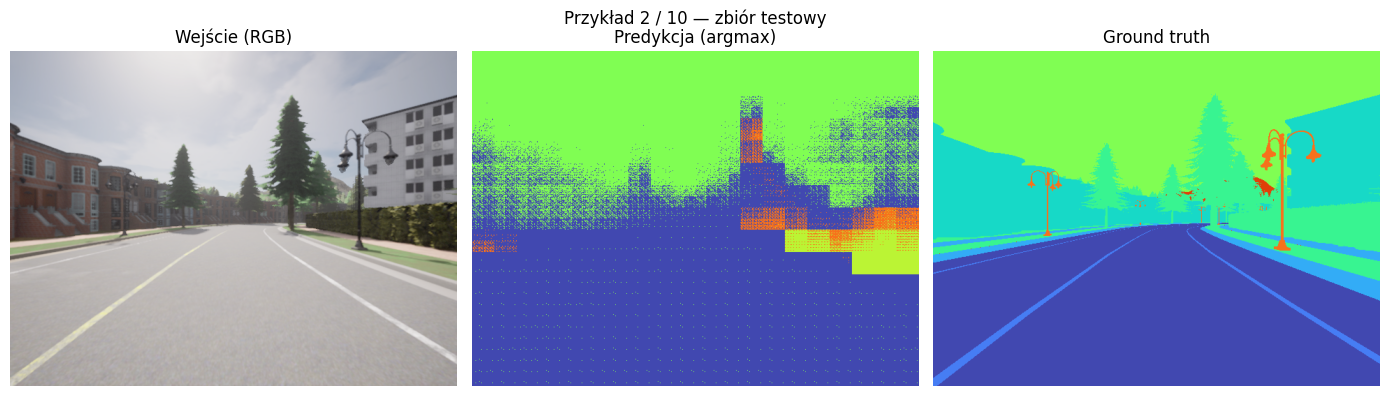

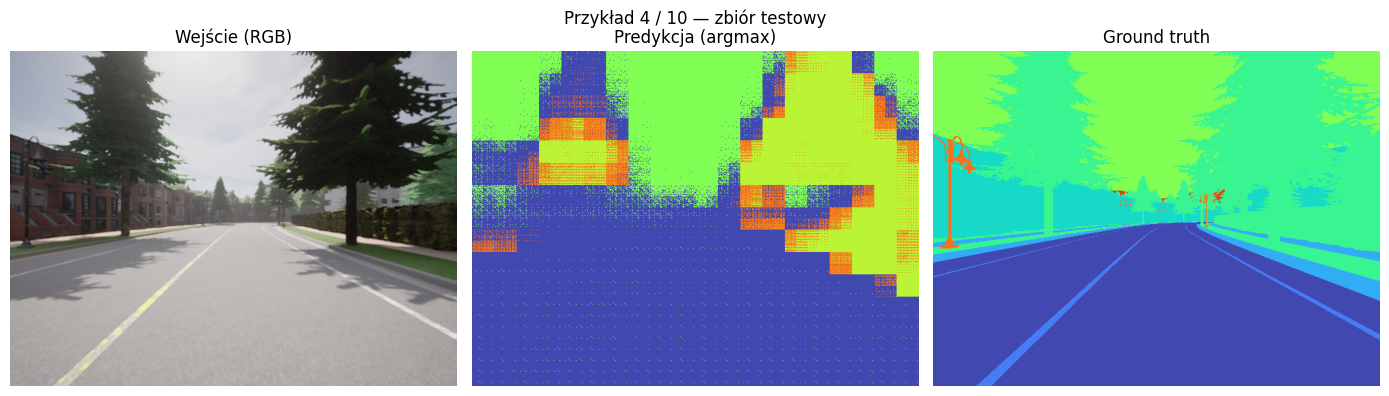

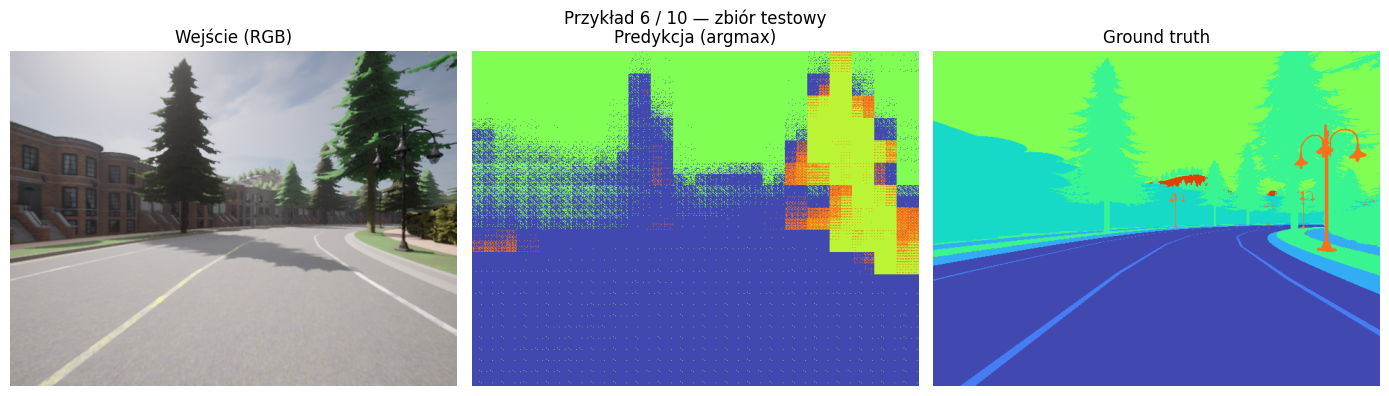

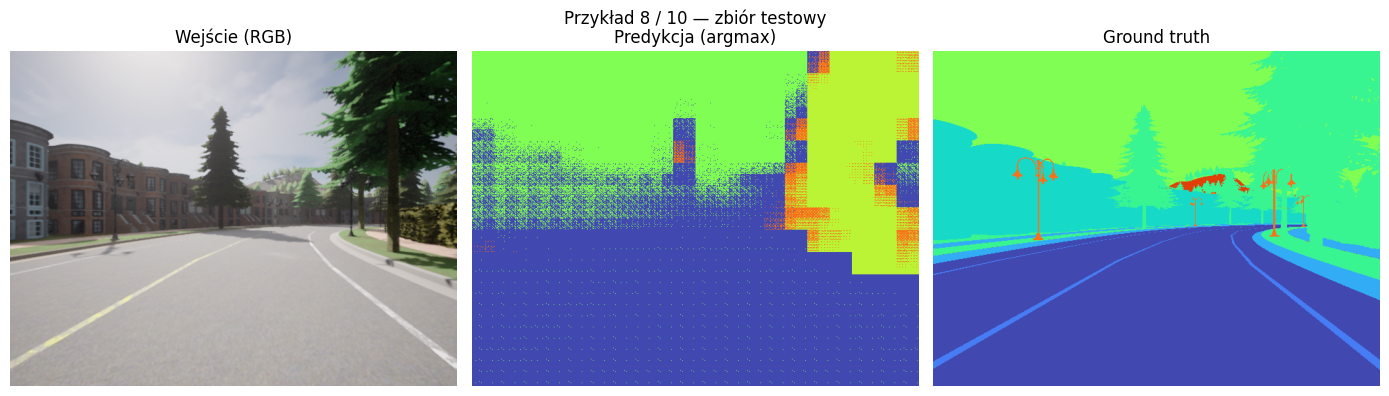

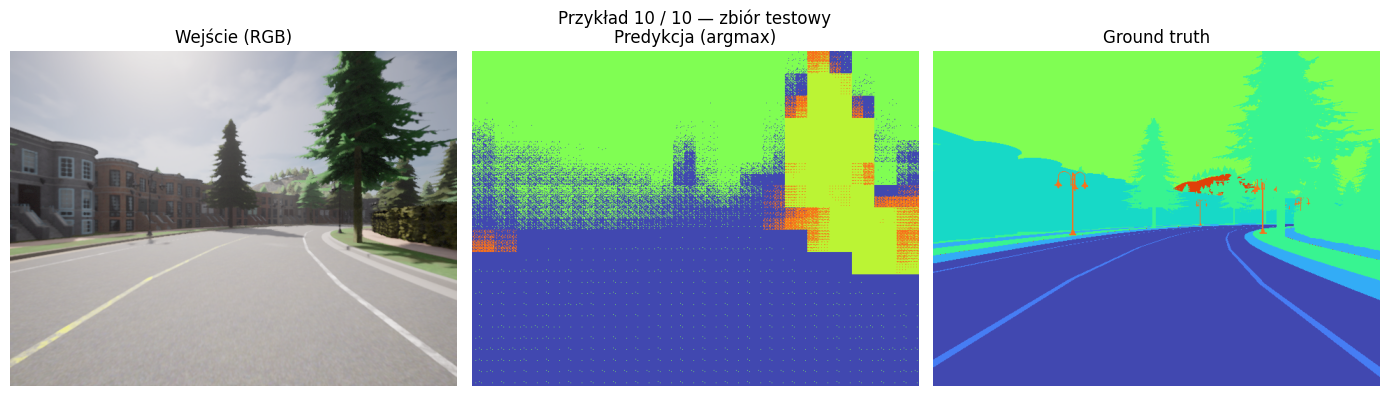

In [ ]:
# Wizualizacja działania modelu (RGB | predykcja | GT)
# Wymaga: CONFIG, NUM_CLASSES, LABEL_LUT, SegModel, F, DataLoader, CARLADataset
# (komórki 1–4). Checkpoint z komórki treningowej lub sam plik .ckpt.

import matplotlib.pyplot as plt

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seg_demo = SegModel(num_classes=NUM_CLASSES).to(_device)
_ckpt = torch.load(CONFIG["checkpoint_path"], map_location=_device)
_sd = {k.replace("model.", "", 1): v for k, v in _ckpt["state_dict"].items() if k.startswith("model.")}
seg_demo.load_state_dict(_sd, strict=True)
seg_demo.eval()

try:
    _loader = test_loader
except NameError:
    _test_ds = CARLADataset(
        CONFIG["data_root"],
        LABEL_LUT,
        max_per_sequence=CONFIG["max_images_per_sequence"],
        sequences=CONFIG["test_sequences"],
    )
    _loader = DataLoader(_test_ds, batch_size=2, shuffle=False, num_workers=0)


def _idx_to_rgb(mask_hw, n_classes):
    lut = (plt.cm.turbo(np.linspace(0, 0.92, n_classes))[:, :3]).astype(np.float32)
    m = np.clip(mask_hw.detach().cpu().numpy(), 0, n_classes - 1)
    return lut[m]


N_SHOW = 10
_shown = 0

import random
# dataset testowy (jeśli masz test_loader z komórki treningowej)
_test_ds = test_loader.dataset
indices = random.sample(range(len(_test_ds)), min(N_SHOW, len(_test_ds)))
# opcjonalnie: random.seed(CONFIG["seed"])  # powtarzalność

with torch.no_grad():
    for idx in indices:
        _imgs, _masks = _test_ds[idx]
        _imgs = _imgs.unsqueeze(0).to(_device)   # (1, C, H, W)
        _masks = _masks.unsqueeze(0)             # (1, H, W)
        _logits = seg_demo(_imgs)
        _logits = F.interpolate(
            _logits, size=_masks.shape[-2:],
            mode="bilinear", align_corners=False,
        )
        _pred = _logits.argmax(dim=1)
        _shown += 1
        _rgb = _imgs[0].cpu().permute(1, 2, 0).numpy()
        for _b in range(_imgs.size(0)):
            if _shown >= N_SHOW:
                break
            _shown += 1
            _rgb = _imgs[_b].cpu().permute(1, 2, 0).numpy()
            _rgb = np.clip(_rgb, 0.0, 1.0)
            _fig, _ax = plt.subplots(1, 3, figsize=(14, 4))
            _ax[0].imshow(_rgb)
            _ax[0].set_title("Wejście (RGB)")
            _ax[0].axis("off")
            _ax[1].imshow(_idx_to_rgb(_pred[_b], NUM_CLASSES))
            _ax[1].set_title("Predykcja (argmax)")
            _ax[1].axis("off")
            _ax[2].imshow(_idx_to_rgb(_masks[_b], NUM_CLASSES))
            _ax[2].set_title("Ground truth")
            _ax[2].axis("off")
            _fig.suptitle(f"Przykład {_shown} / {N_SHOW} — zbiór testowy")
            plt.tight_layout()
            plt.show()
        if _shown >= N_SHOW:
            break

if _shown < N_SHOW:
    print(f"Uwaga: w zbiorze testowym jest tylko {_shown} próbek (pytano o {N_SHOW}).")
